# Week 1 Task: Data Cleaning and Preliminary Analysis with R

**Dataset:** Video Game Sales with Ratings (16,719 titles, 1980–2020)
**Author:** Ram Kumar Gunasekaran
**Tool:** R (base + ggplot2)

This notebook performs data cleaning, preprocessing, missing value treatment, outlier handling, encoding, normalization, and exploratory data analysis on a publicly available video game sales dataset.

## 0. Setup

In [1]:
options(scipen = 999)
library(ggplot2)

df <- read.csv("vgsales_with_ratings.csv", stringsAsFactors = FALSE, na.strings = c("", "N/A", "NA"))
cat("Dataset dimensions:\n")
print(dim(df))

Dataset dimensions:
[1] 16719    16


## 1. Initial Structure & Overview

Inspecting the raw dataset before any cleaning using `str()` and `summary()`.

In [1]:
str(df)

'data.frame':	16719 obs. of  16 variables:
 $ Name           : chr  "Wii Sports" "Super Mario Bros." "Mario Kart Wii" "Wii Sports Resort" ...
 $ Platform       : chr  "Wii" "NES" "Wii" "Wii" ...
 $ Year_of_Release: int  2006 1985 2008 2009 1996 1989 2006 2006 2009 1984 ...
 $ Genre          : chr  "Sports" "Platform" "Racing" "Sports" ...
 $ Publisher      : chr  "Nintendo" "Nintendo" "Nintendo" "Nintendo" ...
 $ NA_Sales       : num  41.4 29.1 15.7 15.6 11.3 ...
 $ EU_Sales       : num  28.96 3.58 12.76 10.93 8.89 ...
 $ JP_Sales       : num  3.77 6.81 3.79 3.28 10.22 ...
 $ Other_Sales    : num  8.45 0.77 3.29 2.95 1 0.58 2.88 2.84 2.24 0.47 ...
 $ Global_Sales   : num  82.5 40.2 35.5 32.8 31.4 ...
 $ Critic_Score   : int  76 NA 82 80 NA NA 89 58 87 NA ...
 $ Critic_Count   : int  51 NA 73 73 NA NA 65 41 80 NA ...
 $ User_Score     : chr  "8" NA "8.3" "8" ...
 $ User_Count     : int  322 NA 709 192 NA NA 431 129 594 NA ...
 $ Developer      : chr  "Nintendo" NA "Nintendo" "Nintendo" 

In [1]:
summary(df)

     Name             Platform         Year_of_Release    Genre          
 Length:16719       Length:16719       Min.   :1980    Length:16719      
 Class :character   Class :character   1st Qu.:2003    Class :character  
 Mode  :character   Mode  :character   Median :2007    Mode  :character  
                                       Mean   :2006                      
                                       3rd Qu.:2010                      
                                       Max.   :2020                      
                                       NA's   :269                       
  Publisher            NA_Sales          EU_Sales         JP_Sales      
 Length:16719       Min.   : 0.0000   Min.   : 0.000   Min.   : 0.0000  
 Class :character   1st Qu.: 0.0000   1st Qu.: 0.000   1st Qu.: 0.0000  
 Mode  :character   Median : 0.0800   Median : 0.020   Median : 0.0000  
                    Mean   : 0.2633   Mean   : 0.145   Mean   : 0.0776  
                    3rd Qu.: 0.2400   3rd Q

In [1]:
head(df, 5)

                      Name Platform Year_of_Release        Genre Publisher
1               Wii Sports      Wii            2006       Sports  Nintendo
2        Super Mario Bros.      NES            1985     Platform  Nintendo
3           Mario Kart Wii      Wii            2008       Racing  Nintendo
4        Wii Sports Resort      Wii            2009       Sports  Nintendo
5 Pokemon Red/Pokemon Blue       GB            1996 Role-Playing  Nintendo
  NA_Sales EU_Sales JP_Sales Other_Sales Global_Sales Critic_Score Critic_Count
1    41.36    28.96     3.77        8.45        82.53           76           51
2    29.08     3.58     6.81        0.77        40.24           NA           NA
3    15.68    12.76     3.79        3.29        35.52           82           73
4    15.61    10.93     3.28        2.95        32.77           80           73
5    11.27     8.89    10.22        1.00        31.37           NA           NA
  User_Score User_Count Developer Rating
1          8        322  Nint

## 2. Missing Value Analysis

A per-column audit quantifies the extent of missingness before choosing a treatment strategy.

In [1]:
missing_summary <- sapply(df, function(x) sum(is.na(x) | x == ""))
print(missing_summary)

missing_pct <- round(100 * missing_summary / nrow(df), 2)
cat("\nMissing value percentage per column:\n")
print(missing_pct)

           Name        Platform Year_of_Release           Genre       Publisher 
              2               0             269               2              54 
       NA_Sales        EU_Sales        JP_Sales     Other_Sales    Global_Sales 
              0               0               0               0               0 
   Critic_Score    Critic_Count      User_Score      User_Count       Developer 
           8582            8582            6704            9129            6623 
         Rating 
           6769 

Missing value percentage per column:
           Name        Platform Year_of_Release           Genre       Publisher 
           0.01            0.00            1.61            0.01            0.32 
       NA_Sales        EU_Sales        JP_Sales     Other_Sales    Global_Sales 
           0.00            0.00            0.00            0.00            0.00 
   Critic_Score    Critic_Count      User_Score      User_Count       Developer 
          51.33           51.33      

Over half of the records lack critic and user review data — a common pattern for older or niche titles that were never professionally reviewed. Rather than dropping these rows (which would discard ~50% of the dataset), a targeted imputation strategy was applied below.

## 3. Data Cleaning

### 3.1 Type Correction

Numeric-looking columns stored as character were explicitly converted, allowing R to coerce invalid placeholder values (e.g. `"tbd"` in `User_Score`) into proper `NA`.

In [ ]:
df$Year_of_Release <- as.numeric(df$Year_of_Release)
df$Critic_Score     <- as.numeric(df$Critic_Score)
df$Critic_Count     <- as.numeric(df$Critic_Count)
df$User_Score       <- as.numeric(df$User_Score)   # 'tbd' becomes NA automatically
df$User_Count       <- as.numeric(df$User_Count)

### 3.2 Drop unusable rows

Rows with no `Name` or `Genre` (2 records) cannot be meaningfully imputed and are dropped outright.

In [ ]:
df <- df[!is.na(df$Name) & !is.na(df$Genre), ]

### 3.3 Handle Missing Values

- **Numerical columns** (`Critic_Score`, `Critic_Count`, `User_Score`, `User_Count`, `Year_of_Release`): imputed with the **column median** — robust to the right-skew present in review-count fields.
- **Categorical columns** (`Publisher`, `Developer`, `Rating`): imputed with the label `"Unknown"` rather than the mode, to avoid artificially inflating any single category.

In [1]:
num_cols <- c("Critic_Score", "Critic_Count", "User_Score", "User_Count", "Year_of_Release")
for (col in num_cols) {
  med_val <- median(df[[col]], na.rm = TRUE)
  df[[col]][is.na(df[[col]])] <- med_val
}

cat_cols <- c("Publisher", "Developer", "Rating")
for (col in cat_cols) {
  df[[col]][is.na(df[[col]]) | df[[col]] == ""] <- "Unknown"
}

cat("Missing values after cleaning:\n")
print(sapply(df, function(x) sum(is.na(x))))

Missing values after cleaning:
           Name        Platform Year_of_Release           Genre       Publisher 
              0               0               0               0               0 
       NA_Sales        EU_Sales        JP_Sales     Other_Sales    Global_Sales 
              0               0               0               0               0 
   Critic_Score    Critic_Count      User_Score      User_Count       Developer 
              0               0               0               0               0 
         Rating 
              0 


### 3.4 Outlier Detection (IQR method)

Outliers in `Global_Sales` were identified using the standard IQR method (1.5 × interquartile range beyond Q1/Q3). Because a strict cutoff would flag thousands of legitimately high-selling titles as "outliers", **deleting them would remove genuine signal**. Instead, sales values were capped at the 95th percentile — preserving all rows while preventing a handful of extreme blockbusters from distorting charts and summary stats.

In [1]:
Q1 <- quantile(df$Global_Sales, 0.25)
Q3 <- quantile(df$Global_Sales, 0.75)
IQR_val <- Q3 - Q1
lower_bound <- Q1 - 1.5 * IQR_val
upper_bound <- Q3 + 1.5 * IQR_val

outliers <- df[df$Global_Sales < lower_bound | df$Global_Sales > upper_bound, ]
cat("Number of outlier rows detected:", nrow(outliers), "\n")
cat("Boundary: Lower =", round(lower_bound,2), " Upper =", round(upper_bound,2), "\n")

cap_val <- quantile(df$Global_Sales, 0.95)
df$Global_Sales_Capped <- ifelse(df$Global_Sales > cap_val, cap_val, df$Global_Sales)
cat("95th percentile cap value applied:", round(cap_val, 2), "\n")

Number of outlier rows detected: 2229 
Boundary: Lower = -0.57  Upper = 0.98 
95th percentile cap value applied: 2.05 


### 3.5 Encoding Categorical Variables

`Genre`, `Platform`, and `Rating` were converted to R factors. `Genre` was additionally one-hot encoded to demonstrate a model-ready transformation.

In [1]:
df$Genre    <- as.factor(df$Genre)
df$Platform <- as.factor(df$Platform)
df$Rating   <- as.factor(df$Rating)

genre_dummies <- model.matrix(~ Genre - 1, data = df)
head(genre_dummies[, 1:5], 5)

  GenreAction GenreAdventure GenreFighting GenreMisc GenrePlatform
1           0              0             0         0             0
2           0              0             0         0             1
3           0              0             0         0             0
4           0              0             0         0             0
5           0              0             0         0             0


### 3.6 Normalization

`Global_Sales_Capped` was scaled to a 0–1 range using min-max normalization, useful for downstream comparison or modeling work.

In [1]:
normalize <- function(x) (x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))
df$Global_Sales_Normalized <- normalize(df$Global_Sales_Capped)
summary(df$Global_Sales_Normalized)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0244  0.0781  0.2405  0.2244  1.0000 


## 4. Exploratory Data Analysis

### 4.1 Correlation Analysis

In [1]:
num_df <- df[, c("Global_Sales", "Critic_Score", "Critic_Count", "User_Score", "User_Count")]
cor_matrix <- cor(num_df, use = "complete.obs")
print(round(cor_matrix, 3))

             Global_Sales Critic_Score Critic_Count User_Score User_Count
Global_Sales        1.000        0.190        0.263      0.049      0.235
Critic_Score        0.190        1.000        0.394      0.479      0.243
Critic_Count        0.263        0.394        1.000      0.119      0.389
User_Score          0.049        0.479        0.119      1.000     -0.006
User_Count          0.235        0.243        0.389     -0.006      1.000


Correlations with `Global_Sales` are weak-to-moderate — `Critic_Count` (0.263) and `User_Count` (0.235) correlate slightly more strongly than the scores themselves, suggesting visibility (review volume) tracks commercial performance somewhat better than review quality. `Critic_Score` and `User_Score` show moderate agreement (0.479).

### 4.2 Sales by Genre

          Genre Global_Sales
1        Action      1745.27
11       Sports      1332.00
9       Shooter      1052.94
8  Role-Playing       934.40
5      Platform       828.08
4          Misc       803.18
7        Racing       728.90
3      Fighting       447.48
10   Simulation       390.42
6        Puzzle       243.02
2     Adventure       237.69
12     Strategy       174.50


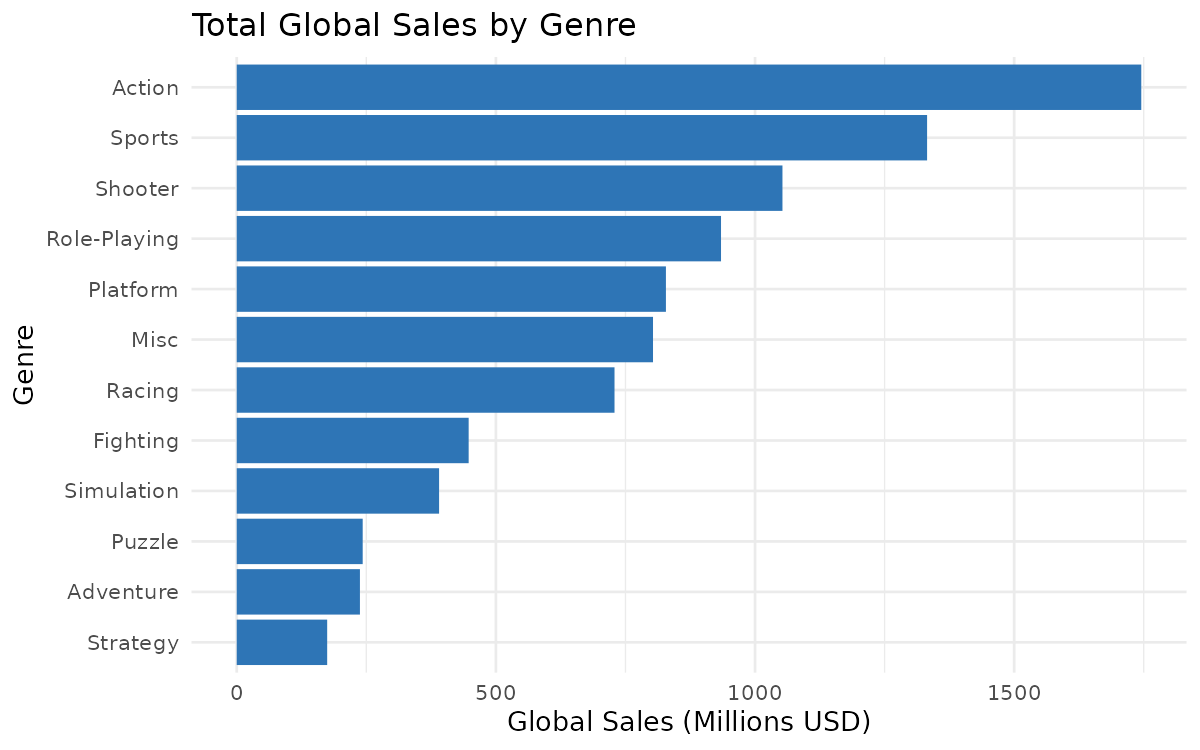

In [1]:
genre_sales <- aggregate(Global_Sales ~ Genre, data = df, sum)
genre_sales <- genre_sales[order(-genre_sales$Global_Sales), ]
print(genre_sales)

p1 <- ggplot(genre_sales, aes(x = reorder(Genre, Global_Sales), y = Global_Sales)) +
  geom_bar(stat = "identity", fill = "#2E75B6") +
  coord_flip() +
  labs(title = "Total Global Sales by Genre", x = "Genre", y = "Global Sales (Millions USD)") +
  theme_minimal(base_size = 13)
p1

**Action** leads with $1,745M in cumulative global sales, followed by **Sports** ($1,332M) and **Shooter** ($1,053M). Strategy and Adventure trail well behind despite many individual titles — indicating a smaller average audience per game in those categories.

### 4.3 Distribution of Sales (Post-Capping)

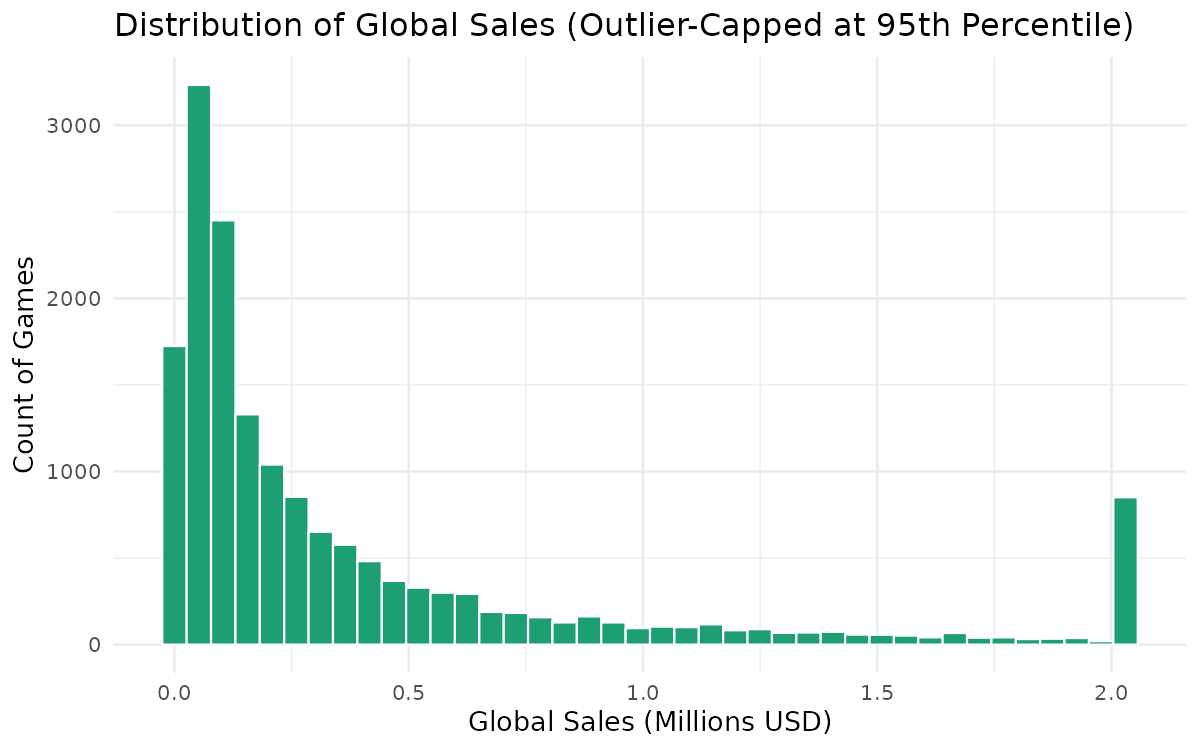

In [1]:
p2 <- ggplot(df, aes(x = Global_Sales_Capped)) +
  geom_histogram(bins = 40, fill = "#1D9E75", color = "white") +
  labs(title = "Distribution of Global Sales (Outlier-Capped at 95th Percentile)",
       x = "Global Sales (Millions USD)", y = "Count of Games") +
  theme_minimal(base_size = 13)
p2

The distribution remains heavily right-skewed even after capping — confirming the video game market follows a hits-driven pattern: a small number of titles capture a disproportionate share of total sales.

### 4.4 Critic Score vs Global Sales

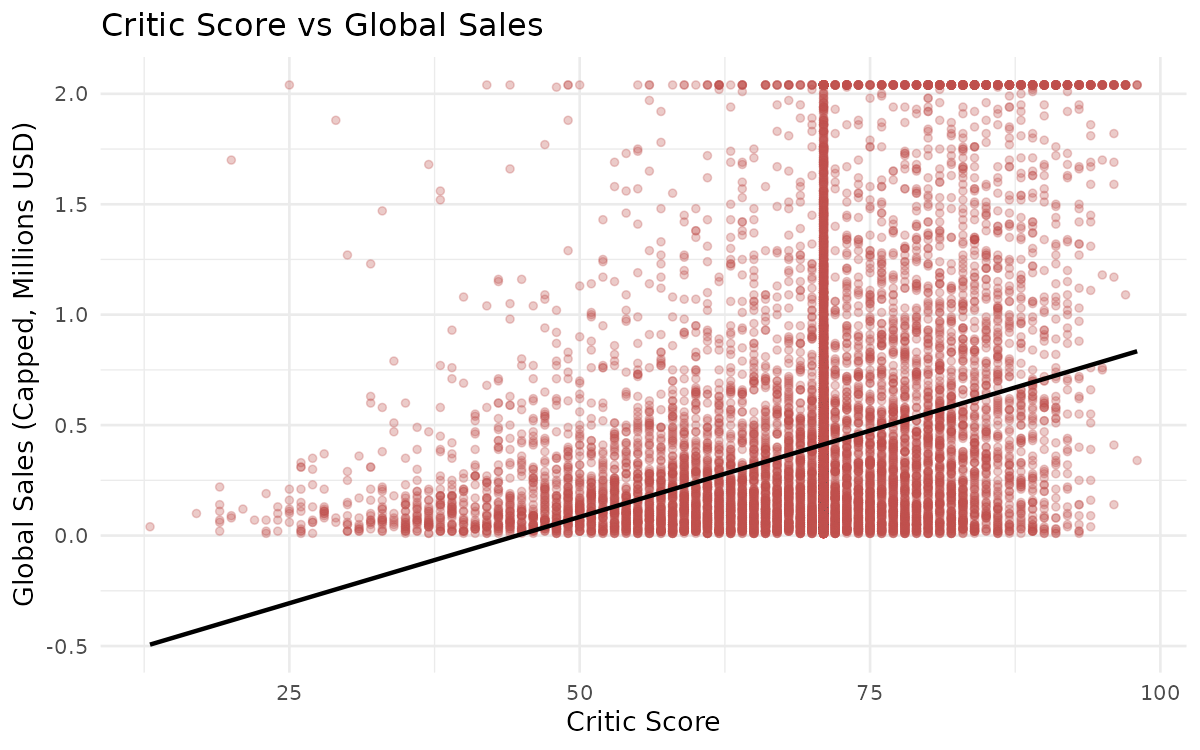

In [1]:
p3 <- ggplot(df, aes(x = Critic_Score, y = Global_Sales_Capped)) +
  geom_point(alpha = 0.3, color = "#C0504D") +
  geom_smooth(method = "lm", color = "black", se = FALSE) +
  labs(title = "Critic Score vs Global Sales", x = "Critic Score", y = "Global Sales (Capped, Millions USD)") +
  theme_minimal(base_size = 13)
p3

The scatter confirms the weak positive correlation (0.19) — a higher critic score does not reliably predict higher sales. Several highly-rated titles sold modestly, while some average-rated titles (helped by brand recognition) sold exceptionally well.

### 4.5 Games Released per Year

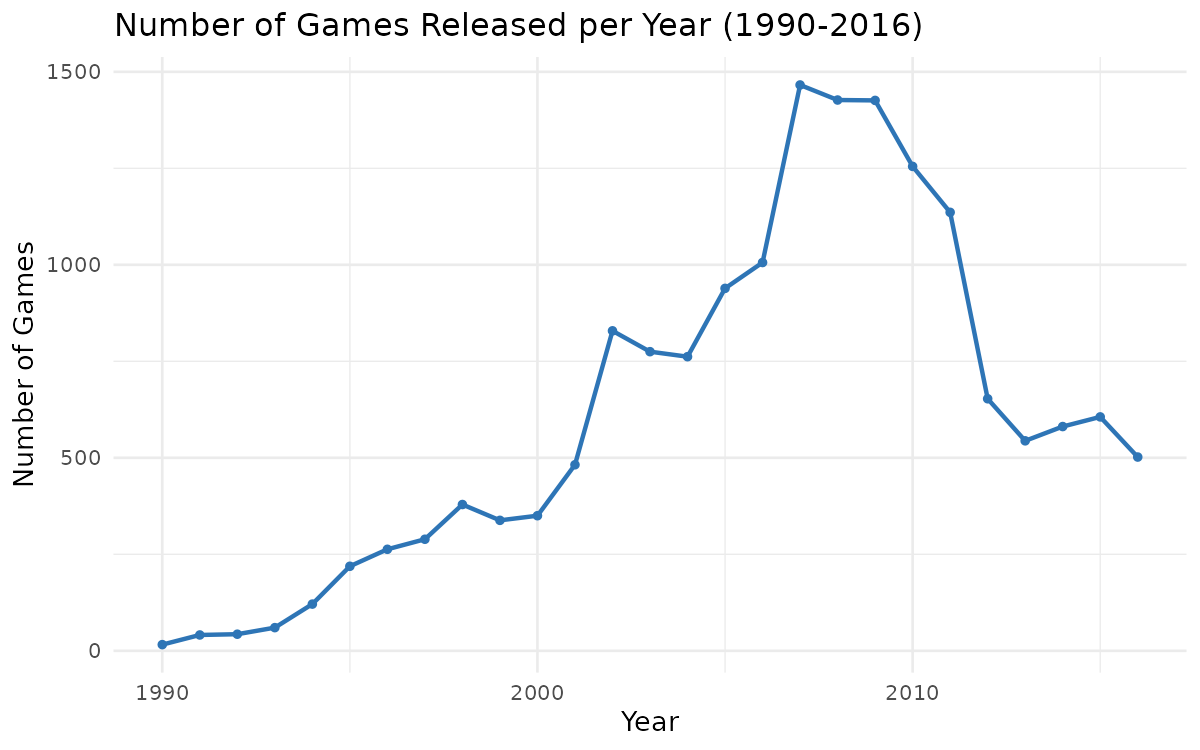

In [1]:
year_counts <- as.data.frame(table(df$Year_of_Release))
colnames(year_counts) <- c("Year", "Count")
year_counts$Year <- as.numeric(as.character(year_counts$Year))
year_counts <- year_counts[year_counts$Year >= 1990 & year_counts$Year <= 2016, ]

p4 <- ggplot(year_counts, aes(x = Year, y = Count)) +
  geom_line(color = "#2E75B6", size = 1) +
  geom_point(color = "#2E75B6") +
  labs(title = "Number of Games Released per Year (1990-2016)", x = "Year", y = "Number of Games") +
  theme_minimal(base_size = 13)
p4

Industry output grew steadily from the 1990s, peaked around 2008–2009 (coinciding with the PS3/Xbox 360/Wii generation), and declined afterward as the dataset's coverage of newer digital-only and mobile titles thins out.

### 4.6 Top Publishers

                       Publisher Global_Sales
362                     Nintendo      1788.81
140              Electronic Arts      1116.96
22                    Activision       731.16
459  Sony Computer Entertainment       606.48
529                      Ubisoft       471.61
498         Take-Two Interactive       403.82
492                          THQ       338.44
278 Konami Digital Entertainment       282.39
449                         Sega       270.35
350           Namco Bandai Games       254.62


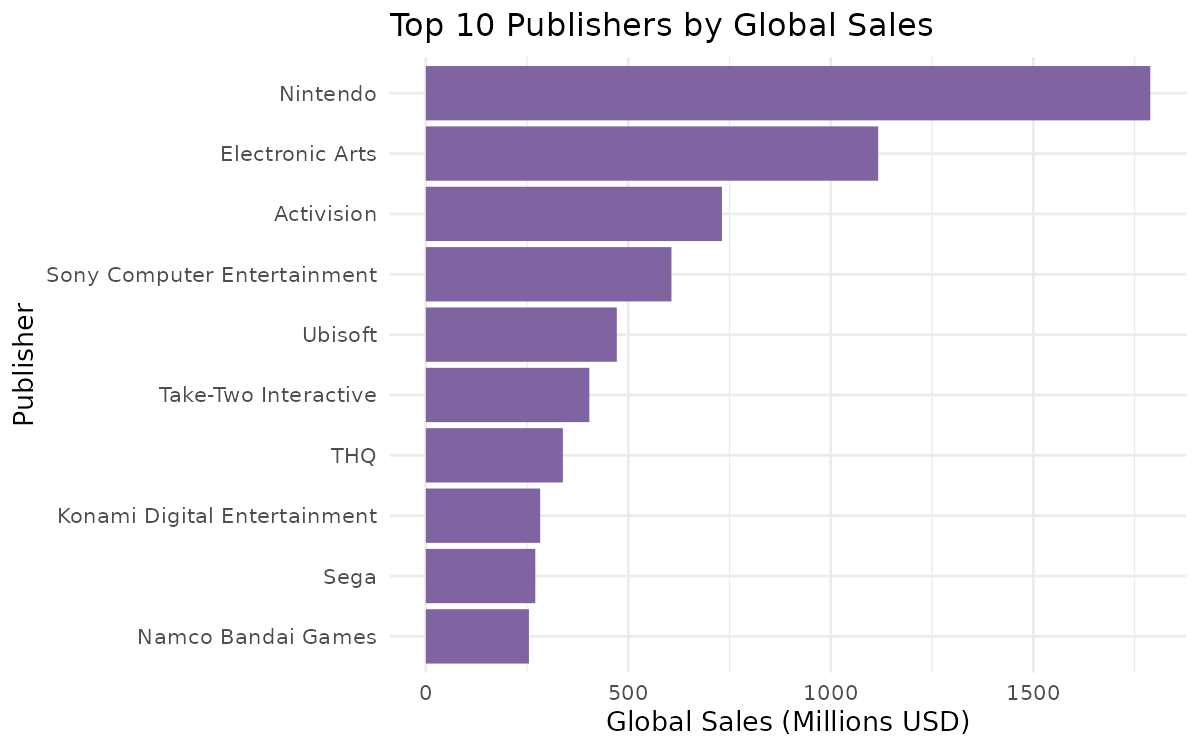

In [1]:
pub_sales <- aggregate(Global_Sales ~ Publisher, data = df, sum)
pub_sales <- pub_sales[order(-pub_sales$Global_Sales), ][1:10, ]
print(pub_sales)

p5 <- ggplot(pub_sales, aes(x = reorder(Publisher, Global_Sales), y = Global_Sales)) +
  geom_bar(stat = "identity", fill = "#8064A2") +
  coord_flip() +
  labs(title = "Top 10 Publishers by Global Sales", x = "Publisher", y = "Global Sales (Millions USD)") +
  theme_minimal(base_size = 13)
p5

**Nintendo** leads by a wide margin at $1,789M, followed by **Electronic Arts** ($1,117M) and **Activision** ($731M) — consistent with Nintendo's first-party dominance across Wii, DS, and GB platforms in this dataset's time range.

## 5. Key Insights Summary

- Roughly half of all review-related fields were missing, driven by unreviewed or older titles — median imputation preserved the full dataset without introducing bias from a skewed mean.
- The sales distribution is extremely right-skewed; a 95th-percentile cap was preferred over deletion to retain hit titles while preventing chart distortion.
- **Action**, **Sports**, and **Shooter** are the highest-grossing genres by cumulative global sales.
- Review scores are weak predictors of commercial sales — visibility metrics (review counts) correlate slightly better than review quality.
- **Nintendo**, **Electronic Arts**, and **Activision** are the top three publishers by total global sales.

## 6. Export Cleaned Dataset

In [1]:
write.csv(df, "vgsales_cleaned.csv", row.names = FALSE)
cat("Cleaned dataset exported as vgsales_cleaned.csv\n")

Cleaned dataset exported as vgsales_cleaned.csv
